# Clean
> Read microcontroller SD-card logs into one flat, quality-flagged DataFrame

Each sensor node (`SP_01`, `SP_02`, ...) writes a CSV log to its SD card. A row is one thermal frame: 768 pixel temperatures from the 32 × 24 MLX90640 camera, plus the soil readings and, on `SP_01` only, the Ruuvi air sensor. Logs from different nodes differ in format and carry sensor faults, and future batches will too.

This module turns any set of logs into one DataFrame with a fixed schema, one row per frame, sorted by node and time. Faulty values are set to missing and flagged, never dropped: the raw logs stay the reference, and each analysis decides what to exclude.

In [ ]:
#| default_exp clean

In [ ]:
#| export
import numpy as np, pandas as pd
from fastcore.utils import *


In [ ]:
import matplotlib.pyplot as plt
from fastcore.test import *

## Reading one log

A log's columns fall into five groups. The schema below fixes their names and order for every node:

In [ ]:
#| export
ruuvi_cols = ['ruuvi_temp', 'ruuvi_humidity', 'ruuvi_pressure']
soil_cols = ['soil_moisture', 'soil_temperature']
leaf_cols = ['leaf_temp_mean', 'leaf_temp_max', 'leaf_temp_min']
px_cols = [f'pixel_{i}' for i in range(768)]
id_cols = ['node_id', 'time', 'timestamp', 'measurement_id', 'frame']
schema = id_cols + ruuvi_cols + soil_cols + leaf_cols + px_cols

The logger writes the date and time as text next to the Unix timestamp, and the Ruuvi columns only when the firmware expects that sensor. So a raw line has one of two layouts, told apart by their field count:

In [ ]:
#| export
raw_id_cols = ['node_id', 'measurement_id', 'frame', 'timestamp', 'date', 'time']
common = soil_cols + leaf_cols + px_cols
layouts = {len(o): o for o in (raw_id_cols + common, raw_id_cols + ruuvi_cols + common)}


In [ ]:
#| export
def _rows2df(rows, cols):
    a, n = np.array(rows), len(raw_id_cols)
    ids = pd.DataFrame(dict(node_id=np.char.strip(a[:, 0]), time=pd.to_datetime(a[:, 3].astype(int), unit='s')))
    ids[['measurement_id', 'frame', 'timestamp']] = a[:, 1:4].astype(int)
    vals = pd.DataFrame(a[:, n:].astype(float), columns=cols[n:]).reindex(columns=ruuvi_cols + common)
    return pd.concat([ids, vals], axis=1)[schema]

def read_log(
    path, # CSV log written by one node
)->pd.DataFrame: # One row per frame, columns in `schema` order, sorted by time and frame
    "Read one node's log into the common schema"
    rows = {}
    with open(path) as f:
        next(f)
        for l in f:
            fs = l.rstrip('\r\n').split(';' if ';' in l else ',')
            rows.setdefault(len(fs), []).append(fs)
    if unknown := set(rows) - set(layouts): raise ValueError(f'{path}: rows with {sorted(unknown)} fields match no known layout')
    df = pd.concat([_rows2df(v, layouts[n]) for n,v in rows.items()]).replace(-999, np.nan)
    return df.sort_values(['time', 'frame'], ignore_index=True)

A log is not one table. The logger appends lines, and a single file can mix formats: `SP_02` switches from `;` to `,` delimiters across an outage in late September, and its first ten lines after the switch use `SP_01`'s Ruuvi layout. So `read_log` splits each line on its own delimiter and picks the column layout from its field count. A field count matching no known layout raises an error: a new firmware format should be noticed, not guessed.

Beyond that, `read_log` strips the leading space from `node_id`, adds the Ruuvi columns as missing for nodes without that sensor, and turns the `-999` the logger writes for "no reading" into missing values.

`time` comes from the Unix `timestamp`, which encodes Austrian local time (it converts to the same wall-clock time the logger writes in its `date` and `time` columns). Those two text columns are dropped: they repeat `timestamp`, in a format that varies even within one file (`2026-09-23` versus `23/09/2026`).


In [ ]:
#| eval: false
data = Path('../data/b01')
sp2 = read_log(data/'dados_SP_02.csv')
sp2.iloc[:3, :12]

,node_id,time,timestamp,measurement_id,frame,ruuvi_temp,ruuvi_humidity,ruuvi_pressure,soil_moisture,soil_temperature,leaf_temp_mean,leaf_temp_max
0,SP_02,2026-09-23 11:49:21,1790164161,5967213,1,NaN,NaN,NaN,24.5,22.5,26.02,31.39
1,SP_02,2026-09-23 11:49:21,1790164161,5967213,2,NaN,NaN,NaN,24.5,22.5,25.98,31.73
2,SP_02,2026-09-23 11:49:21,1790164161,5967213,3,NaN,NaN,NaN,24.5,22.5,26.09,31.12


## All logs in one table

In [ ]:
#| export
def read_logs(
    paths, # CSV logs, one or more per node
)->pd.DataFrame: # One row per frame for all nodes, sorted by node, time and frame
    "Read logs from all nodes into one table"
    df = pd.concat([read_log(p) for p in paths], ignore_index=True)
    return df.sort_values(['node_id', 'time', 'frame'], ignore_index=True)

A node may leave several logs, for instance one per SD-card import, so `read_logs` takes any list of paths:

In [ ]:
#| eval: false
df = read_logs(sorted(data.glob('dados_*.csv')))
df.groupby('node_id').time.agg(['count', 'min', 'max'])

,count,min,max
node_id,,,
SP_01,9159,2026-09-23 11:58:45,2026-10-05 16:45:00
SP_02,12185,2026-09-23 11:49:21,2026-10-05 16:50:00
SP_03,9991,2026-09-23 11:42:19,2026-10-05 16:50:00
SP_04,14170,2026-09-23 11:37:37,2026-10-05 16:45:00


## Quality flags

Sensors sometimes return values no plant or soil can have: a pixel at 877 °C or −253 °C after a faulty camera read, or a soil moisture of exactly 0 when the probe drops out. `limits` holds the open interval of plausible values for each measurement:

In [ ]:
#| export
limits = dict(pixel=(0, 60), soil_moisture=(0, 100), soil_temperature=(0, 60))

In [ ]:
#| export
def _leaf(p): return pd.DataFrame(dict(leaf_temp_mean=p.mean(axis=1), leaf_temp_max=p.max(axis=1), leaf_temp_min=p.min(axis=1)))
def clean(
    df:pd.DataFrame, # Output of `read_logs`
    limits:dict=limits, # Open interval of plausible values per measurement
)->pd.DataFrame: # Same rows, implausible values missing, with `qc_*` flag columns
    "Set implausible values to missing, flag them, and recompute leaf summaries from the remaining pixels"
    bad = lambda x, k: (x <= limits[k][0]) | (x >= limits[k][1])
    p = df[px_cols].mask(bad(df[px_cols], 'pixel'))
    soil = pd.DataFrame({c: df[c].mask(bad(df[c], c)) for c in soil_cols})
    leaf = _leaf(p)
    n_bad_px = (p.isna() & df[px_cols].notna()).sum(axis=1)
    soil_lost = (soil.isna() & df[soil_cols].notna()).any(axis=1)
    qc = pd.DataFrame(dict(qc_bad_px=n_bad_px, qc_soil=soil_lost))
    return pd.concat([df[id_cols + ruuvi_cols], soil, leaf, qc, p], axis=1)

`clean` keeps every row. A value outside its limits becomes missing, and a flag column records that it was there: `qc_bad_px` counts the pixels removed from each frame, and `qc_soil` marks rows that lost a soil reading. Values the logger never had (its `-999`) are simply missing, without a flag. The leaf summaries are recomputed from the remaining pixels, since the logger's own summaries include the faulty ones: a single 877 °C pixel would otherwise set `leaf_temp_max`.

In [ ]:
#| eval: false
cdf = clean(df)
cdf.groupby('node_id')[['qc_bad_px', 'qc_soil']].agg(lambda s: (s > 0).sum())

,qc_bad_px,qc_soil
node_id,,
SP_01,22,5
SP_02,150,0
SP_03,212,0
SP_04,109,0


The raw maximum leaf temperature reaches several hundred degrees; after cleaning, it stays within the limits:

In [ ]:
#| eval: false
test_eq(cdf.leaf_temp_max.max() < limits['pixel'][1], True)
df.leaf_temp_max.max(), cdf.leaf_temp_max.max()

(np.float64(877.1), np.float64(59.99))

## One row per measurement

Every 5 minutes, a node takes a burst of usually 5 frames within one second. All frames in a burst share `measurement_id` and `time`. The firmware reads the soil and Ruuvi sensors once per burst, so each frame's row repeats the same values. The pixels differ by about 0.3 °C from frame to frame, which looks like camera noise.

`measurements` combines each burst into one row. Each pixel becomes its median across the burst's frames, so one faulty frame doesn't move the result. Run it after `clean`, so pixels outside the limits are already missing and don't count.

In [ ]:
#| export
def measurements(
    df:pd.DataFrame, # Output of `clean`
)->pd.DataFrame: # One row per node and time, with the median image of the burst
    "Combine each burst of frames into one measurement"
    g = df.groupby(['node_id', 'time'])
    p = g[px_cols].median()
    ids = g[['timestamp', 'measurement_id']].first().assign(n_frames=g.size())
    env = g[ruuvi_cols + soil_cols].median()
    qc = g.agg(qc_bad_px=('qc_bad_px', 'sum'), qc_soil=('qc_soil', 'any'))
    return pd.concat([ids, env, _leaf(p), qc, p], axis=1).reset_index()

`n_frames` counts the frames in the burst. The leaf summaries are recomputed from the median image. `qc_bad_px` is the number of pixel readings removed from the whole burst, and `qc_soil` is true if any frame lost a soil reading. In batch 1, each frame with no valid pixel sits in a burst with good frames, so every measurement has an image:

In [ ]:
#| eval: false
mdf = measurements(cdf)
test_eq(mdf[px_cols].isna().all(axis=1).sum(), 0)
mdf.groupby('node_id').n_frames.value_counts().unstack(fill_value=0)

n_frames,2,4,5
node_id,,,
SP_01,0,1,1831
SP_02,0,0,2437
SP_03,1,1,1997
SP_04,0,0,2834


## Air readings for every node

The nodes share one greenhouse, and the single Ruuvi sensor is wired to `SP_01`. Its air temperature, humidity and pressure therefore apply to every plant, and leaf minus air temperature is a key input to the crop water stress index. `share_ruuvi` copies the `source` node's Ruuvi readings to every node. It matches each row to the nearest valid reading in time, within `tolerance`. The node clocks agree to about a second, so half of the 5-minute step is a safe tolerance. A row with no reading within `tolerance`, for instance during an outage of `SP_01`, gets missing values.

In [ ]:
#| export
def share_ruuvi(
    df:pd.DataFrame, # Output of `clean` or `measurements`
    source:str='SP_01', # Node with the Ruuvi sensor
    tolerance:str='150s', # Largest time difference to the matched reading
)->pd.DataFrame: # Same rows, with the source node's Ruuvi readings on every node
    "Copy the Ruuvi readings of `source` to every node, matched by time"
    src = df.loc[df.node_id == source, ['time'] + ruuvi_cols].dropna().rename(columns={'time': 't_src'})
    s = df[['time']].sort_values('time')
    m = pd.merge_asof(s, src, left_on='time', right_on='t_src', direction='nearest', tolerance=pd.Timedelta(tolerance))
    m.index = s.index
    return df.assign(**{c: m[c] for c in ruuvi_cols})

Share of measurements with an air temperature, per node. Outside the outages of `SP_01`, every node has one:

In [ ]:
#| eval: false
mdf = share_ruuvi(mdf)
mdf.groupby('node_id').ruuvi_temp.apply(lambda s: s.notna().mean()).round(2)

node_id
SP_01    0.85
SP_02    0.58
SP_03    0.71
SP_04    0.51
Name: ruuvi_temp, dtype: float64

## Thermal images

In [ ]:
#| export
def frames(
    df:pd.DataFrame, # Rows of `read_logs`, `clean` or `measurements` output
)->np.ndarray: # Shape `(len(df), 24, 32)`, one thermal image per row
    "Thermal images of the frames in `df`"
    return df[px_cols].to_numpy().reshape(-1, 24, 32)

Each row's 768 pixels are one 24 × 32 image, stored row by row. `frames` reshapes them, so any selection of rows, by node, time or flag, gives an image stack. Here is the first frame of each node:

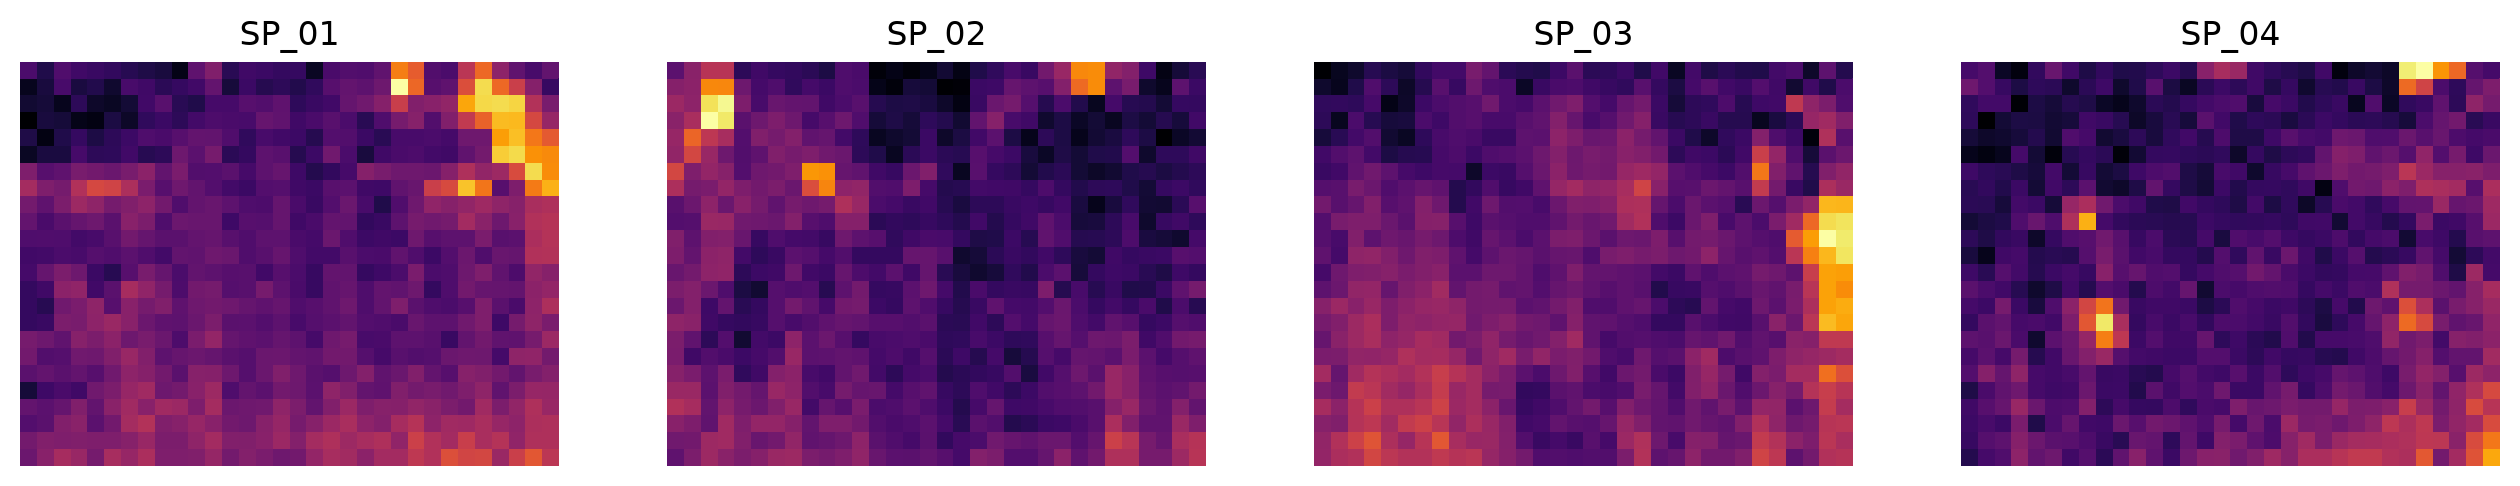

In [ ]:
#| eval: false
first = cdf.groupby('node_id').head(1)
fig, axs = plt.subplots(1, len(first), figsize=(16, 3))
for ax, im, node in zip(axs, frames(first), first.node_id):
    ax.imshow(im, cmap='inferno')
    ax.set_title(node)
    ax.axis('off')

## Quality report

In [ ]:
#| export
def qc_report(
    df:pd.DataFrame, # Output of `clean`
    max_step='15min', # Longest expected interval between measurements
)->pd.DataFrame: # One row per node
    "Per-node summary of coverage, gaps and quality flags"
    def _node(d):
        t = d.time.drop_duplicates()
        gaps = t.diff()
        res = dict(frames=len(d), measurements=len(t), first=t.min(), last=t.max())
        res |= dict(gaps=(gaps > pd.Timedelta(max_step)).sum(), longest_gap=gaps.max())
        res |= {f'{c}_%': round(100*d[c].notna().mean(), 1) for c in ['ruuvi_temp', *soil_cols]}
        res |= dict(frames_bad_px=(d.qc_bad_px > 0).sum(), frames_no_px=d.leaf_temp_mean.isna().sum(), soil_flagged=d.qc_soil.sum())
        return pd.Series(res)
    return df.groupby('node_id').apply(_node)

`qc_report` summarises a batch per node: its time span, the number of gaps longer than `max_step`, the share of rows with each environmental reading, and the frames and rows affected by the quality flags. `frames_no_px` counts frames with no valid pixel left, either because the camera returned nothing or because every pixel was implausible.

In [ ]:
#| eval: false
rep = qc_report(cdf)
rep.T

node_id,SP_01,SP_02,SP_03,SP_04
frames,9159,12185,9991,14170
measurements,1832,2437,1999,2834
first,2026-09-23 11:58:45,2026-09-23 11:49:21,2026-09-23 11:42:19,2026-09-23 11:37:37
last,2026-10-05 16:45:00,2026-10-05 16:50:00,2026-10-05 16:50:00,2026-10-05 16:45:00
gaps,6,4,7,5
longest_gap,2 days 08:36:05,2 days 22:09:08,2 days 07:15:16,1 days 07:41:09
ruuvi_temp_%,85.2,0.0,0.0,0.0
soil_moisture_%,99.9,21.7,15.3,100.0
soil_temperature_%,100.0,14.2,15.3,100.0
frames_bad_px,22,150,212,109


In [ ]:
#| export
def find_gaps(
    df:pd.DataFrame, # Output of `read_logs` or `clean`
    max_step='15min', # Longest expected interval between measurements
)->pd.DataFrame: # One row per gap: node, last measurement before it, first after it, and duration
    "Intervals longer than `max_step` without a measurement, per node"
    def _node(d):
        t = d.time.drop_duplicates()
        return pd.DataFrame(dict(node_id=d.node_id.iloc[0], start=t.shift(), end=t, duration=t.diff()))
    res = pd.concat([_node(d) for _,d in df.groupby('node_id')])
    return res[res.duration > pd.Timedelta(max_step)].reset_index(drop=True)

`find_gaps` lists the outages behind the `gaps` count, to line them up across nodes:

In [ ]:
#| eval: false
gaps = find_gaps(cdf)
gaps

,node_id,start,end,duration
0,SP_01,2026-09-23 18:05:00,2026-09-24 10:16:55,0 days 16:11:55
1,SP_01,2026-09-24 10:30:00,2026-09-24 14:19:12,0 days 03:49:12
2,SP_01,2026-09-24 14:19:12,2026-09-24 14:40:37,0 days 00:21:25
3,SP_01,2026-09-26 03:35:00,2026-09-28 09:14:11,2 days 05:39:11
4,SP_01,2026-09-30 03:50:00,2026-09-30 13:45:02,0 days 09:55:02
5,SP_01,2026-10-02 23:45:01,2026-10-05 08:21:06,2 days 08:36:05
6,SP_02,2026-09-24 00:05:01,2026-09-24 10:19:29,0 days 10:14:28
7,SP_02,2026-09-25 17:30:00,2026-09-28 15:39:08,2 days 22:09:08
8,SP_02,2026-09-30 05:35:01,2026-09-30 13:44:19,0 days 08:09:18
9,SP_02,2026-10-01 12:00:01,2026-10-01 14:07:37,0 days 02:07:36
